# SalesForce Pro Inc. - Exploratory Data Analysis
### Analysing 4 years of revenue data (2021–2024) across 49,728 orders

In [1]:
# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# loading the cleaned dataset
df = pd.read_csv('salesforce_pro_cleaned.csv')

print(df.shape)
df.head()

(49728, 27)


,order_id,order_date,ship_date,delivery_date,customer_id,customer_name,segment,region,state,sales_rep_id,...,profit,payment_method,ship_mode,return_flag,customer_rating,order_year,order_month,order_quarter,delivery_days,profit_margin
0,ORD017864,2022-02-19,2022-02-22,2022-02-25,CUST02439,Vinay Gupta,Government,West,Madhya Pradesh,REP014,...,111978.08,EMI,Standard,0,5.0,2022,2,1,6,18.05
1,ORD009550,2024-11-26,2024-12-09,2024-12-11,CUST06324,Sneha Singh,Education,North,Punjab,REP041,...,260463.87,Credit Card,Economy,0,4.0,2024,11,4,15,52.90
2,ORD045511,2024-07-10,2024-07-10,2024-07-13,CUST07230,Rohit Malhotra,Government,North,Punjab,REP013,...,12448.36,UPI,Same Day,0,3.0,2024,7,3,3,19.06
3,ORD039181,2023-06-15,2023-06-20,2023-06-24,CUST00213,Vikram Dubey,Education,East,Assam,REP003,...,72194.81,EMI,Standard,0,2.0,2023,6,2,9,52.48
4,ORD023367,2022-08-09,2022-08-16,2022-08-19,CUST01399,Deepa Malhotra,Startup,East,Jharkhand,REP006,...,16402.88,Credit Card,Standard,0,3.0,2022,8,3,10,55.56


In [2]:
total_revenue = df['sales_amount'].sum()
total_profit  = df['profit'].sum()
total_orders  = df['order_id'].nunique()
total_customers = df['customer_id'].nunique()
avg_order_value = df['sales_amount'].mean()

In [3]:
print(f"Total Revenue    : ₹{total_revenue:,.0f}")
print(f"Total Profit     : ₹{total_profit:,.0f}")
print(f"Total Orders     : {total_orders:,}")
print(f"Unique Customers : {total_customers:,}")
print(f"Avg Order Value  : ₹{avg_order_value:,.0f}")
print(f"Overall Margin % : {(total_profit/total_revenue*100):.1f}%")

Total Revenue    : ₹12,763,555,347
Total Profit     : ₹3,410,065,850
Total Orders     : 49,723
Unique Customers : 7,984
Avg Order Value  : ₹256,667
Overall Margin % : 26.7%


In [5]:
# grouping revenue by year to see if the business is growing
yearly = df.groupby('order_year')[['sales_amount', 'profit']].sum() / 10000000
yearly.columns = ['revenue_cr', 'profit_cr']
yearly['margin_pct'] = (yearly['profit_cr'] / yearly['revenue_cr'] * 100).round(1)
yearly['growth_pct'] = yearly['revenue_cr'].pct_change().mul(100).round(1)
print(yearly.round(2))

            revenue_cr  profit_cr  margin_pct  growth_pct
order_year                                               
2021            168.34      44.90        26.7         NaN
2022            245.12      65.36        26.7        45.6
2023            355.40      94.82        26.7        45.0
2024            507.50     135.93        26.8        42.8


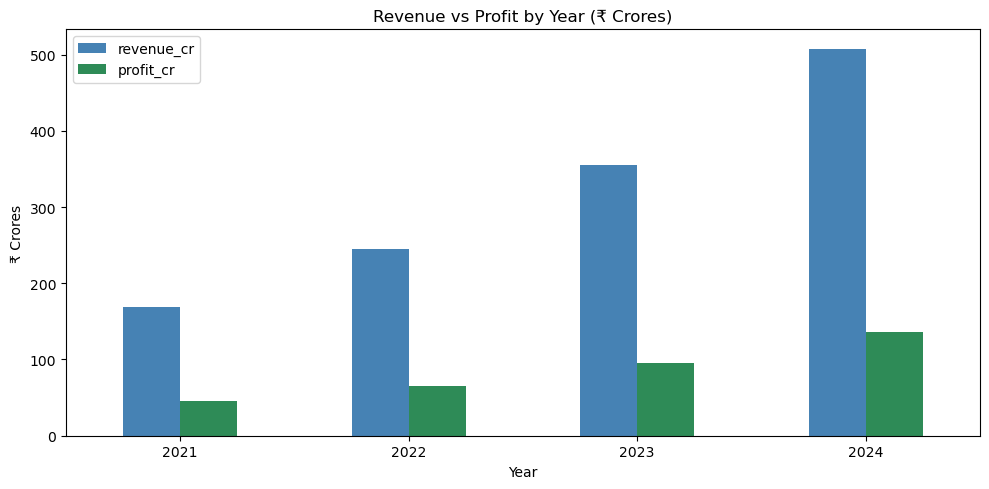

In [ ]:
# plotting
yearly[['revenue_cr', 'profit_cr']].plot(kind='bar',figsize=(10, 5),color=['steelblue', 'seagreen'])
plt.title('Revenue vs Profit by Year (₹ Crores)')
plt.xlabel('Year')
plt.ylabel('₹ Crores')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [7]:
# which category brings in the most revenue
category = df.groupby('category')[['sales_amount', 'profit']].sum() / 10000000
category.columns = ['revenue_cr', 'profit_cr']
category['margin_pct'] = (category['profit_cr'] / category['revenue_cr'] * 100).round(1)
category = category.sort_values('revenue_cr', ascending=False)
print(category.round(2))

                 revenue_cr  profit_cr  margin_pct
category                                          
Electronics          574.96     103.75        18.0
Furniture            383.80      84.60        22.0
Software             238.26     130.96        55.0
Clothing              69.80      20.94        30.0
Office Supplies        9.54       0.75         7.9


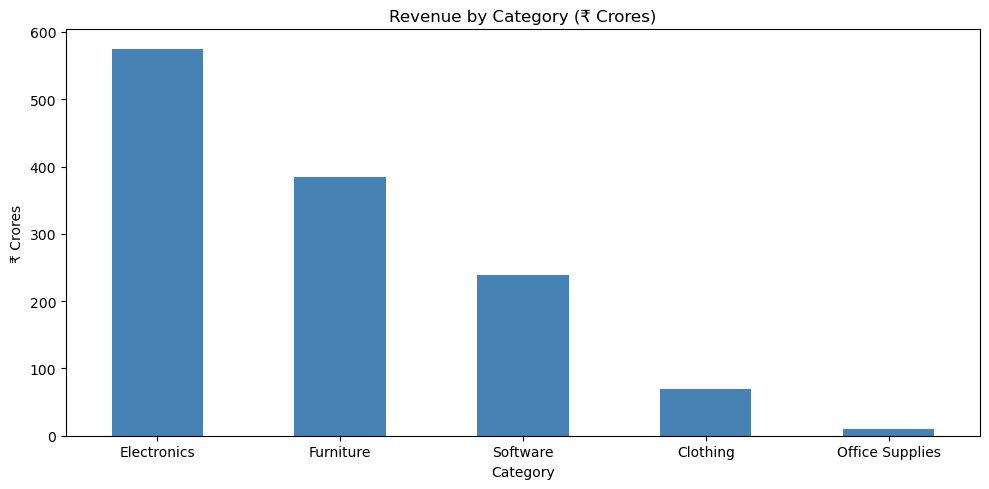

In [8]:
# plotting
category['revenue_cr'].plot(kind='bar', figsize=(10, 5), color='steelblue')
plt.title('Revenue by Category (₹ Crores)')
plt.xlabel('Category')
plt.ylabel('₹ Crores')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Electronics looks like the star category at ₹574 Cr revenue, but when I looked at profit margins, Software at 55% margin was actually generating more profit than Electronics at 18% margin. My recommendation to the business would be to invest more in Software sales since it gives higher returns compared to Electronics.

In [9]:
# which region is performing best
region = df.groupby('region')[['sales_amount', 'profit']].sum() / 10000000
region.columns = ['revenue_cr', 'profit_cr']
region['margin_pct'] = (region['profit_cr'] / region['revenue_cr'] * 100).round(1)
region = region.sort_values('revenue_cr', ascending=False)
print(region.round(2))

         revenue_cr  profit_cr  margin_pct
region                                    
East         263.33      70.83        26.9
North        256.06      67.85        26.5
Central      254.10      67.98        26.8
South        253.92      67.40        26.5
West         248.94      66.94        26.9


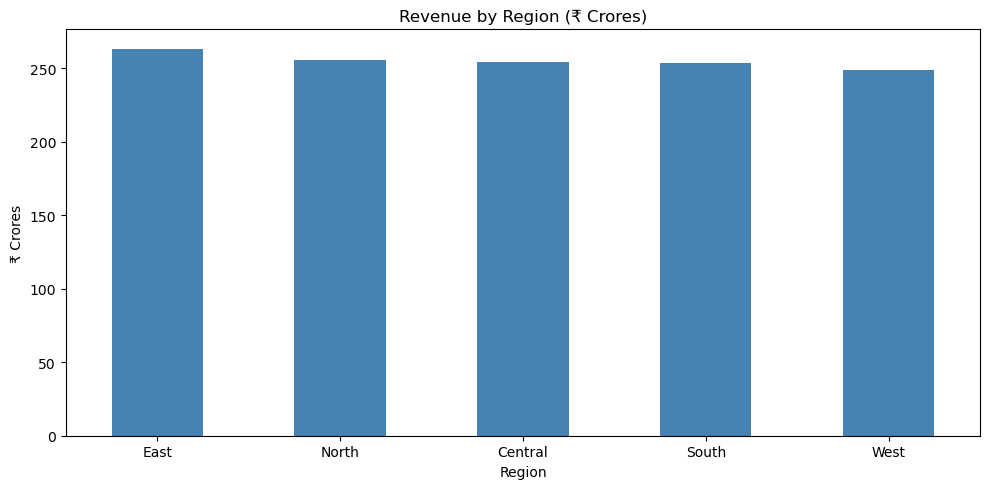

In [10]:
# plotting
region['revenue_cr'].plot(kind='bar', figsize=(10, 5), color='steelblue')
plt.title('Revenue by Region (₹ Crores)')
plt.xlabel('Region')
plt.ylabel('₹ Crores')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [11]:
# which category sells best in which region
region_category = df.groupby(['region', 'category'])['sales_amount'].sum().unstack() / 10000000
print(region_category.round(1))

category  Clothing  Electronics  Furniture  Office Supplies  Software
region                                                               
Central       14.5        114.5       75.6              1.9      47.6
East          14.4        119.0       77.6              1.9      50.5
North         14.0        115.6       78.6              1.9      45.9
South         13.1        115.8       76.5              1.9      46.6
West          13.9        110.0       75.5              1.9      47.6


**Revenue by Region**

Revenue is evenly distributed across all five regions, ranging from ₹248 Cr to ₹263 Cr, with consistent profit margins of 26–27%. This indicates a uniform pricing and discount strategy across the country.

**Key Insight:** No region shows significant underperformance. However, Office Supplies generates only ₹1.9 Cr in every region, making it a company-wide category concern rather than a regional issue. The category requires strategic improvement or reevaluation.


In [13]:
# checking which customer segment brings the most revenue
segment = df.groupby('segment')['sales_amount'].sum().sort_values(ascending=False)
print(segment)

segment
Education     2.606370e+09
Startup       2.587021e+09
SMB           2.569666e+09
Enterprise    2.526639e+09
Government    2.473859e+09
Name: sales_amount, dtype: float64


In [15]:
# converting to crores for readability
segment_cr = (segment / 10000000).round(2)
print(segment_cr)

segment
Education     260.64
Startup       258.70
SMB           256.97
Enterprise    252.66
Government    247.39
Name: sales_amount, dtype: float64


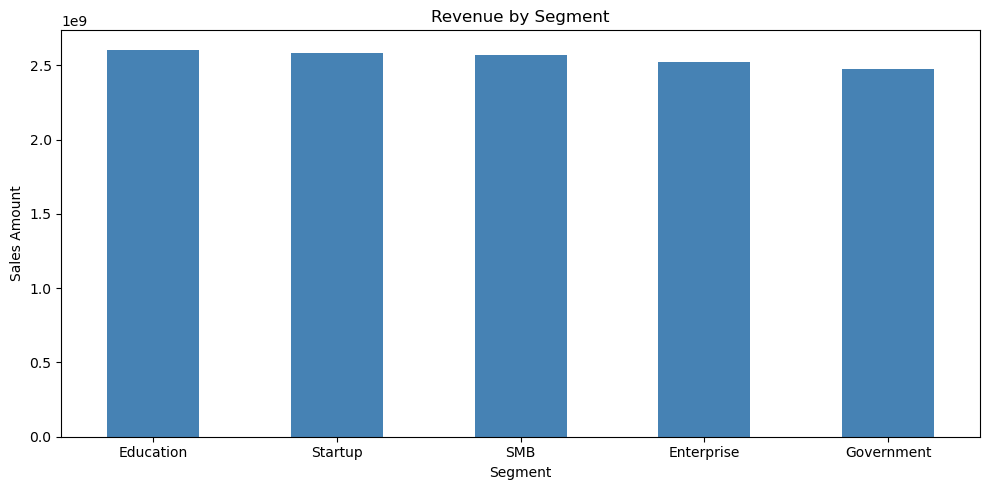

In [16]:
# plotting
segment.plot(kind='bar', figsize=(10, 5), color='steelblue')
plt.title('Revenue by Segment')
plt.xlabel('Segment')
plt.ylabel('Sales Amount')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [17]:
# average order value by segment
avg_order = (df.groupby('segment')['sales_amount'].mean()).round(2)
print(avg_order)

segment
Education     259572.77
Enterprise    257610.06
Government    248904.18
SMB           259798.36
Startup       257440.69
Name: sales_amount, dtype: float64


All 5 segments contribute almost equally to revenue at around ₹250-260 Crores each, with average order values of ₹2.5 Lakhs , so the business isn't dependent on any single segment, which is a healthy sign.

Jan     87.79
Feb     86.60
Mar     97.95
Apr     97.64
May    104.58
Jun    100.94
Jul    105.20
Aug    112.24
Sep    117.42
Oct    117.94
Nov    122.51
Dec    125.55
Name: sales_amount, dtype: float64


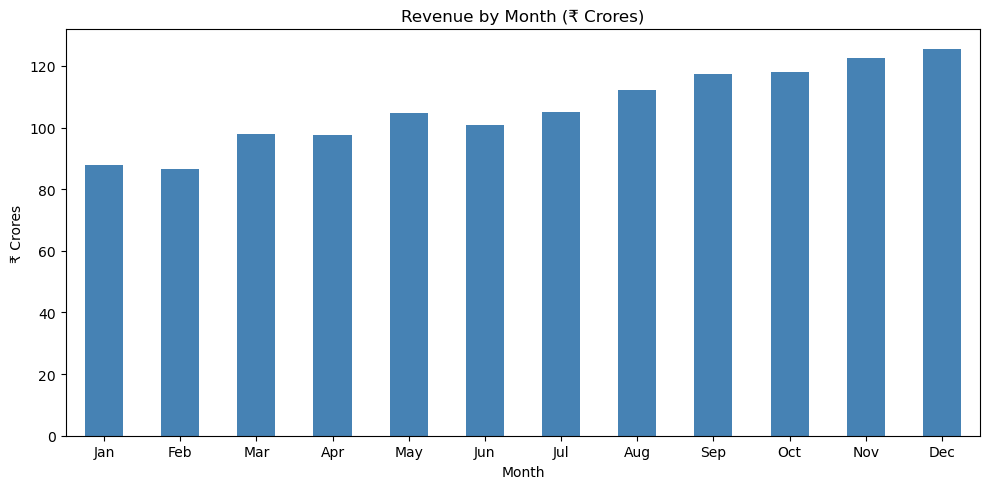

In [19]:
# checking if revenue changes month to month
monthly = df.groupby('order_month')['sales_amount'].sum() / 10000000
monthly.index = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

print(monthly.round(2))

monthly.plot(kind='bar', figsize=(10, 5), color='steelblue')
plt.title('Revenue by Month (₹ Crores)')
plt.xlabel('Month')
plt.ylabel('₹ Crores')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

          sales_amount    profit
discount                        
0.00         292407.89  78518.08
0.05         275610.41  73761.47
0.10         259245.18  69092.41
0.15         248162.80  65777.87
0.20         230881.17  61083.43
0.25         212790.90  57472.06
0.30         204067.78  53883.42


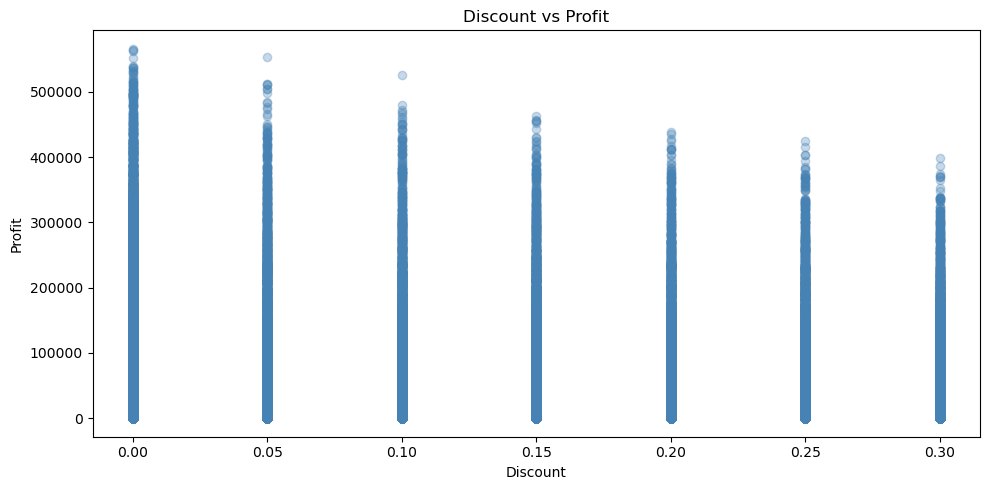

In [20]:
# checking if giving more discount is hurting our profit
discount_profit = df.groupby('discount')[['sales_amount', 'profit']].mean().round(2)
print(discount_profit)

# plotting
plt.figure(figsize=(10, 5))
plt.scatter(df['discount'], df['profit'], alpha=0.3, color='steelblue')
plt.title('Discount vs Profit')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.tight_layout()
plt.show()

As discount increases, both sales amount and profit drop consistently. When there is no discount, average profit is ₹78,518. When discount is 30%, average profit drops to ₹53,883 , that's a 31% drop in profit.

product_name
Samsung Galaxy     62.76
Asus ROG           61.30
Sony WH1000        59.84
Lenovo ThinkPad    59.08
Dell Laptop        57.57
iPhone 14          56.13
Logitech MX        55.49
HP Pavilion        54.41
iPad Pro           54.38
Canon EOS          54.02
Name: sales_amount, dtype: float64


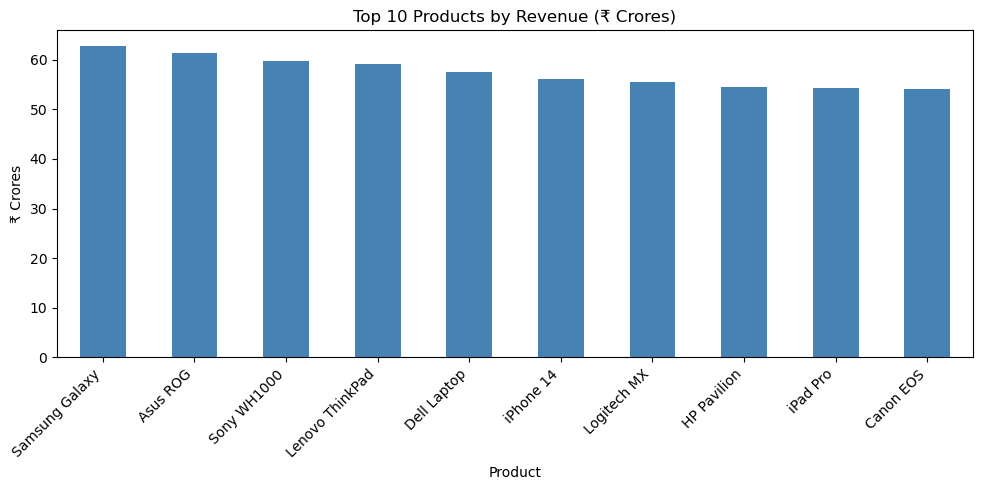

In [21]:
# which products are bringing in the most revenue
top_products = df.groupby('product_name')['sales_amount'].sum() / 10000000
top_products = top_products.sort_values(ascending=False).head(10)

print(top_products.round(2))

# plotting
top_products.plot(kind='bar', figsize=(10, 5), color='steelblue')
plt.title('Top 10 Products by Revenue (₹ Crores)')
plt.xlabel('Product')
plt.ylabel('₹ Crores')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Every single top 10 product is from the Electronics category. Samsung Galaxy leads at ₹62.76 Cr, followed by Asus ROG at ₹61.30 Cr. The gap between first and tenth is only ₹8 Cr .As seen previously electronics has the highest revenue but lowest margin at 18%. So these top 10 products are driving maximum sales but keeping the least profit.

In [22]:
# top 10 by profit 
top_profit = df.groupby('product_name')['profit'].sum() / 10000000
top_profit = top_profit.sort_values(ascending=False).head(10)
print(top_profit.round(2))

product_name
QuickBooks        13.76
Power BI Pro      13.74
Slack Pro         13.48
Zoom Business     13.44
Norton 360        13.23
MS Office 365     13.07
Salesforce CRM    12.94
Zoho CRM          12.77
SAP ERP           12.46
Tally Prime       12.09
Name: profit, dtype: float64


Top 10 by revenue are all Electronics, top 10 by profit are all Software , not a single product overlaps.

sales_rep_id
REP015    27.68
REP047    27.56
REP043    27.44
REP027    27.40
REP008    27.30
REP004    27.06
REP009    27.04
REP048    26.87
REP039    26.73
REP022    26.65
Name: sales_amount, dtype: float64


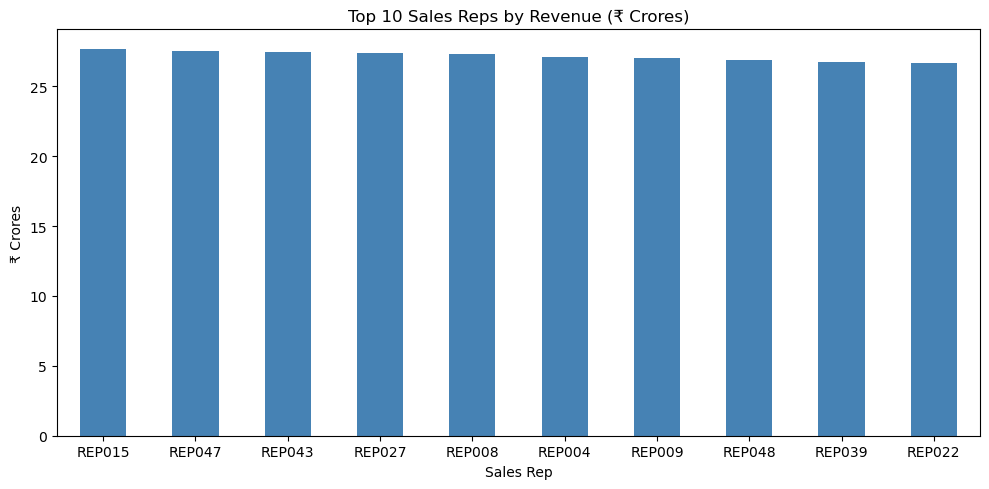

In [28]:
# top 10 sales reps by revenue
sales_rep = df.groupby('sales_rep_id')['sales_amount'].sum() / 10000000
sales_rep = sales_rep.sort_values(ascending=False).head(10).round(2)
print(sales_rep)

# plotting
sales_rep.plot(kind='bar', figsize=(10, 5), color='steelblue')
plt.title('Top 10 Sales Reps by Revenue (₹ Crores)')
plt.xlabel('Sales Rep')
plt.ylabel('₹ Crores')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [29]:
# top 5 and bottom 5 sales reps
top5    = sales_rep.head(5)
bottom5 = (df.groupby('sales_rep_id')['sales_amount'].sum() / 10000000).sort_values().head(5).round(2)

print('Top 5 reps:')
print(top5)
print()
print('Bottom 5 reps:')
print(bottom5)

Top 5 reps:
sales_rep_id
REP015    27.68
REP047    27.56
REP043    27.44
REP027    27.40
REP008    27.30
Name: sales_amount, dtype: float64

Bottom 5 reps:
sales_rep_id
UNASSIGNED     1.66
REP010        22.60
REP028        22.76
REP050        23.69
REP042        23.87
Name: sales_amount, dtype: float64


Through this EDA I found that SalesForce Pro Inc. is a fast growing business that tripled revenue in 4 years. The biggest strategic insight is that Electronics drives revenue but Software drives profit and these are completely different product sets. The company is also over-discounting which is hurting margins by 31%. My recommendation would be to push Software sales, set a maximum discount threshold, and assign untracked orders to a dedicated channel for proper accountability.